# Step 0
### Pull ticker data and make a basic buy/sell signal

[Geeks for Geeks](https://www.geeksforgeeks.org/python/get-financial-data-from-yahoo-finance-with-python/?cs=0&hl=en-US&biw=1536&bih=695.2000122070312)


In [11]:
import yfinance as yf

meta = yf.Ticker("META")
for key, value in meta.info.items():
    print(f"{key}: {value}")

address1: 1 Meta Way
city: Menlo Park
state: CA
zip: 94025
country: United States
phone: 650 543 4800
website: https://www.meta.com
industry: Internet Content & Information
industryKey: internet-content-information
industryDisp: Internet Content & Information
sector: Communication Services
sectorKey: communication-services
sectorDisp: Communication Services
longBusinessSummary: Meta Platforms, Inc. engages in the development of products that enable people to connect and share with friends and family through mobile devices, personal computers, virtual reality (VR) headsets, and AI glasses in the United States, Canada, Europe, Asia-Pacific, and internationally. It operates through two segments, Family of Apps (FoA) and Reality Labs (RL). The FoA segment offers Facebook, which enables people to build community through feed, reels, stories, groups, marketplace, and other; Instagram that brings people closer through Instagram feed, stories, reels, live, and messaging; Messenger, a messaging

In [12]:
spy = yf.Ticker("SPY")
spy_history = spy.history(period="20y")
spy_history.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2006-06-12 00:00:00-04:00,87.005158,87.039719,85.581339,85.698837,95815900,0.000,0.0,0.0
2006-06-13 00:00:00-04:00,85.526032,86.286324,84.703537,84.703537,185688800,0.000,0.0,0.0
2006-06-14 00:00:00-04:00,84.903990,85.450019,84.558402,85.360168,163566400,0.000,0.0,0.0
2006-06-15 00:00:00-04:00,85.671166,87.336901,85.608963,87.171021,134057000,0.000,0.0,0.0
2006-06-16 00:00:00-04:00,86.980135,87.167575,86.403922,86.535828,94253500,0.555,0.0,0.0


<Axes: title={'center': 'SPY Closing Price Over Time'}, xlabel='Date', ylabel='Closing Price (USD)'>

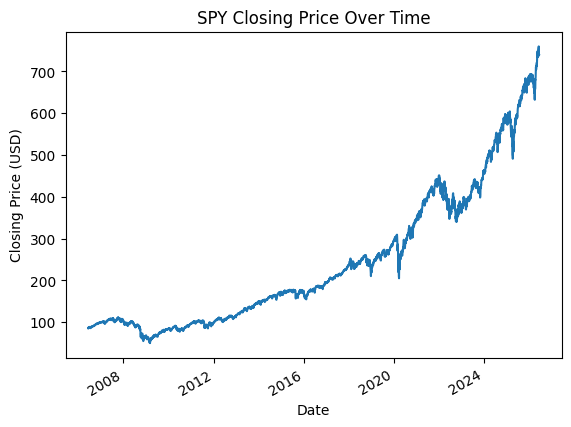

In [13]:
spy_history['Close'].plot(
    title="SPY Closing Price Over Time",
    xlabel="Date",
    ylabel="Closing Price (USD)"
)

# Basic Signal 

In [18]:
import numpy as np

df = spy_history.copy()

fast_ma      = df['Close'].rolling(window=10).mean()
slow_ma      = df['Close'].rolling(window=160).mean()
df['signal'] = np.where(fast_ma > slow_ma, 1, 0)

df['return']          = np.log(df['Close']).diff().shift(-1)
df['strategy_return'] = df['signal'] * df['return']

r = df['strategy_return']

profit_factor = r[r > 0].sum() / r[r < 0].abs().sum()
sharpe_ratio  = r.mean() / r.std()

sharpe_ratio, profit_factor




(np.float64(0.039572618891820836), np.float64(1.1360868833610007))

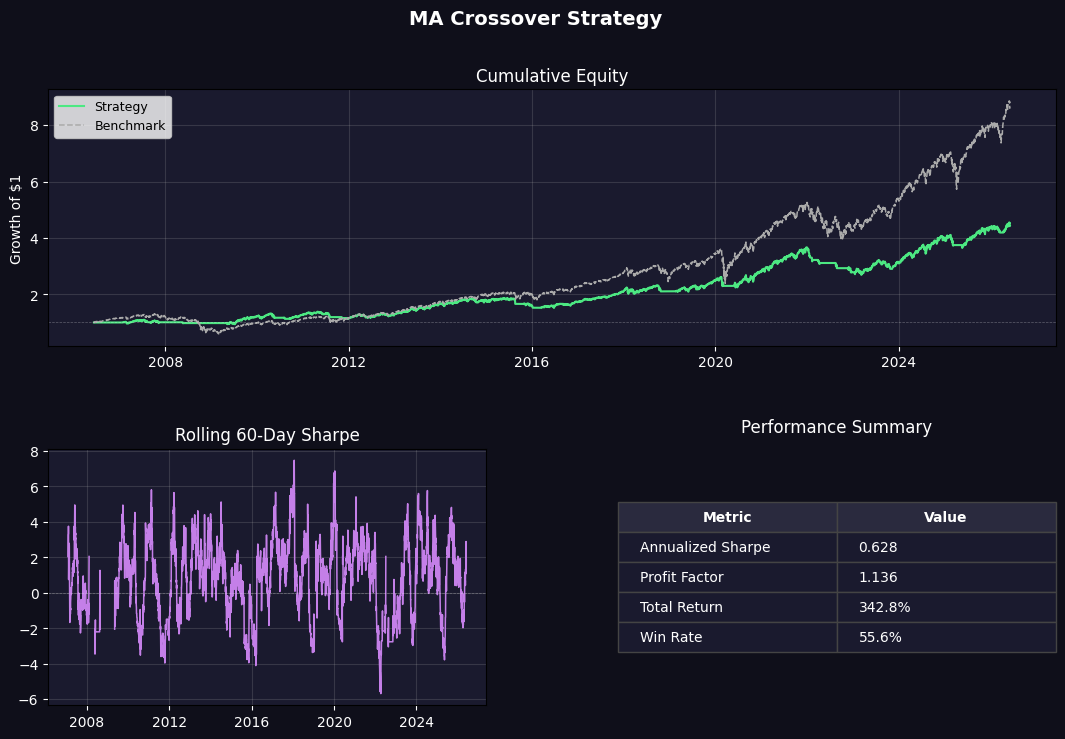

{'sharpe': np.float64(0.6282),
 'profit_factor': np.float64(1.1361),
 'total_return': np.float64(3.4276),
 'win_rate': np.float64(0.5565)}

In [19]:
from trading_dashboard import trading_dashboard

trading_dashboard(
    df['strategy_return']
    , benchmark_returns = df['return']
    , title             = "MA Crossover Strategy"
)